<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter5_Model_Evaluation_and_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 - Model Evaluation and Improvement

Notebook ini berisi ringkasan materi dan reproduksi kode dari **Chapter 5** buku *Introduction to Machine Learning with Python*.

Pada chapter ini, fokus utamanya adalah bagaimana mengevaluasi model machine learning dengan cara yang lebih baik. Jika pada chapter sebelumnya kita sudah mencoba beberapa model, maka di chapter ini kita belajar bagaimana memastikan bahwa model yang dibuat memang benar-benar bagus dan tidak hanya terlihat bagus pada satu pembagian data saja.

Beberapa topik utama yang dibahas:
- cross-validation
- grid search
- evaluasi parameter model
- pemilihan metrik evaluasi
- penggunaan pipeline untuk mencegah data leakage

## Ringkasan Chapter

Dari chapter ini saya memahami bahwa **train-test split saja kadang belum cukup** untuk menilai kualitas model. Hasil model bisa saja terlihat bagus hanya karena kebetulan pembagian datanya menguntungkan. Oleh karena itu, diperlukan evaluasi yang lebih stabil seperti **cross-validation**.

Selain itu, chapter ini juga membahas **grid search** untuk mencari kombinasi parameter terbaik secara sistematis. Buku menekankan bahwa pemilihan parameter sangat berpengaruh terhadap performa model, sehingga proses tuning tidak boleh dilakukan sembarangan.

Di bagian akhir, chapter ini juga menunjukkan pentingnya **pipeline**, yaitu cara menggabungkan preprocessing dan model dalam satu alur kerja agar proses training dan evaluasi menjadi lebih aman dan rapi.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold, ShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score

## 1. Persiapan Dataset

Untuk contoh pertama, saya menggunakan **dataset Iris** karena dataset ini cukup sederhana dan sering dipakai untuk demonstrasi klasifikasi.

Tujuan dari bagian ini adalah menyiapkan data sebelum masuk ke evaluasi model. Setelah data dimuat, kita akan membaginya menjadi data training dan data test.

In [37]:
# Load dataset iris
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (112, 4)
X_test shape : (38, 4)
y_train shape: (112,)
y_test shape : (38,)


## 2. Evaluasi Sederhana dengan Train-Test Split

Cara paling dasar untuk mengevaluasi model adalah dengan membagi data menjadi dua bagian:
- **training set** untuk melatih model
- **test set** untuk menguji model

Cara ini mudah dipahami, tetapi hasilnya masih sangat bergantung pada satu pembagian data saja. Kalau pembagian datanya berbeda, hasil akurasinya juga bisa berubah.

In [38]:
# Contoh model SVC sederhana
svc = SVC()
svc.fit(X_train, y_train)

train_score = svc.score(X_train, y_train)
test_score = svc.score(X_test, y_test)

print("Training accuracy:", round(train_score, 3))
print("Test accuracy    :", round(test_score, 3))

Training accuracy: 0.964
Test accuracy    : 0.974


### Interpretasi

Dari hasil di atas, kita bisa melihat akurasi model pada data training dan data test. Nilai ini memberi gambaran awal tentang performa model. Namun, hasil ini belum tentu stabil karena hanya berasal dari satu kali pembagian data.

Karena itu, chapter ini memperkenalkan **cross-validation** sebagai cara evaluasi yang lebih kuat.

## 3. Cross-Validation

Cross-validation digunakan untuk mengevaluasi model dengan lebih stabil. Ide utamanya adalah data tidak hanya dibagi sekali, tetapi dibagi menjadi beberapa bagian atau **fold**.

Misalnya jika memakai **5-fold cross-validation**, maka data dibagi menjadi 5 bagian. Model akan dilatih pada 4 bagian dan diuji pada 1 bagian, lalu proses ini diulang sampai semua bagian pernah menjadi data uji.

Keuntungan utamanya:
- hasil evaluasi lebih stabil
- tidak terlalu bergantung pada satu pembagian data
- lebih representatif untuk melihat kemampuan generalisasi model

In [39]:
# Cross-validation pada dataset iris
scores = cross_val_score(SVC(), X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score       :", scores.mean())

Cross-validation scores: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Average CV score       : 0.9666666666666666


### Interpretasi

Output di atas menunjukkan akurasi model pada masing-masing fold. Nilai rata-ratanya biasanya lebih dapat dipercaya dibanding satu kali train-test split, karena model diuji pada beberapa pembagian data yang berbeda.

Kalau skor antar-fold mirip satu sama lain, itu biasanya menandakan model cukup stabil.

## 4. K-Fold Cross-Validation

Secara default, `cross_val_score()` biasanya menggunakan pembagian fold standar. Namun, kita juga bisa mengatur sendiri bagaimana fold dibentuk, misalnya dengan **KFold**.

Dengan KFold, kita bisa mengatur:
- jumlah fold
- apakah data diacak atau tidak
- random state untuk hasil yang konsisten

In [40]:
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
scores_kfold = cross_val_score(SVC(), X, y, cv=kfold)

print("KFold CV scores:", scores_kfold)
print("Average KFold CV score:", scores_kfold.mean())

KFold CV scores: [1.         0.8        1.         0.96666667 0.93333333]
Average KFold CV score: 0.9400000000000001


## 5. Shuffle Split Cross-Validation

Selain KFold, buku juga memperkenalkan **ShuffleSplit**. Pada metode ini, data diacak dan dibagi berkali-kali menjadi training set dan test set.

Metode ini berguna ketika kita ingin melakukan evaluasi berulang dengan pembagian acak yang berbeda-beda.

In [41]:
shuffle_split = ShuffleSplit(test_size=0.5, train_size=0.5, n_splits=10, random_state=0)
scores_shuffle = cross_val_score(SVC(), X, y, cv=shuffle_split)

print("ShuffleSplit CV scores:", scores_shuffle)
print("Average ShuffleSplit score:", scores_shuffle.mean())

ShuffleSplit CV scores: [0.94666667 0.94666667 0.97333333 0.94666667 0.94666667 0.94666667
 0.94666667 0.97333333 0.98666667 0.97333333]
Average ShuffleSplit score: 0.9586666666666666


## 6. Grid Search

Setelah model dievaluasi, langkah berikutnya adalah mencari parameter terbaik. Di sinilah **grid search** digunakan.

Grid search bekerja dengan mencoba beberapa kombinasi parameter secara sistematis, lalu memilih kombinasi yang memberikan performa terbaik pada validasi.

Contohnya pada model SVM, parameter yang sering dicoba adalah:
- `C`
- `gamma`

In [42]:
# Membagi data lagi untuk contoh grid search
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", round(grid_search.best_score_, 3))

Best parameters: {'C': 10, 'gamma': 0.1}
Best cross-validation score: 0.973


### Interpretasi

Dari hasil grid search, kita bisa melihat kombinasi parameter terbaik berdasarkan cross-validation. Ini lebih baik dibanding memilih parameter secara asal, karena model benar-benar diuji pada beberapa kemungkinan nilai parameter.

Dengan cara ini, proses tuning model menjadi lebih terarah.

## 7. Evaluasi Model Hasil Grid Search pada Test Set

Setelah mendapatkan parameter terbaik dari data training, model tersebut kemudian diuji pada **test set**. Ini penting karena test set harus tetap menjadi data yang benar-benar baru bagi model.

Jika performa pada test set juga bagus, berarti model tersebut memiliki generalisasi yang baik.

In [43]:
test_score = grid_search.score(X_test, y_test)
print("Test set score with best parameters:", round(test_score, 3))

Test set score with best parameters: 0.974


## 8. Melihat Hasil Grid Search dalam Bentuk Tabel

Agar lebih mudah dianalisis, hasil dari semua kombinasi parameter bisa diubah menjadi tabel. Dengan begitu, kita bisa melihat mana parameter yang menghasilkan skor tertinggi dan bagaimana perbedaan performa antar-kombinasi.

In [44]:
results = pd.DataFrame(grid_search.cv_results_)
results[["param_C", "param_gamma", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score").head(10)

,param_C,param_gamma,mean_test_score,rank_test_score
10,10.0,0.100,0.973123,1
13,100.0,0.010,0.964427,2
6,1.0,0.100,0.964032,3
12,100.0,0.001,0.964032,3
9,10.0,0.010,0.964032,3
3,0.1,1.000,0.955336,6
14,100.0,0.100,0.954941,7
7,1.0,1.000,0.946640,8
15,100.0,1.000,0.946245,9
11,10.0,1.000,0.946245,9


## 9. Visualisasi Hasil Grid Search

Supaya pola hasil tuning lebih mudah dilihat, skor dari grid search bisa divisualisasikan ke dalam bentuk heatmap sederhana. Visualisasi ini membantu kita melihat kombinasi parameter mana yang cenderung bagus dan mana yang kurang baik.

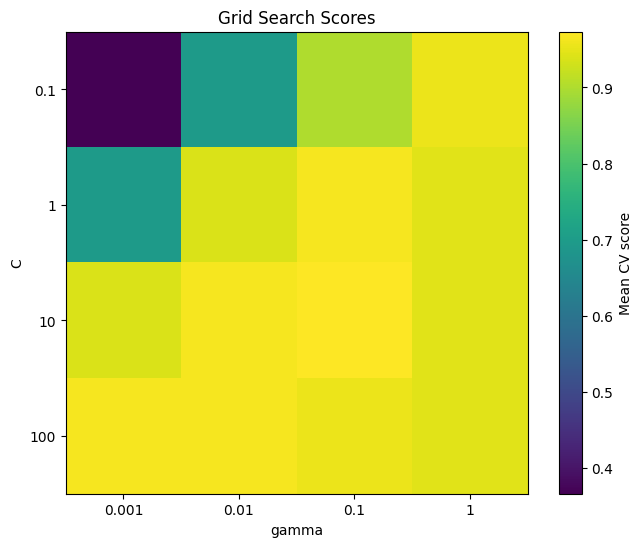

In [45]:
scores = np.array(results.mean_test_score).reshape(4, 4)

plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation='nearest', cmap='viridis')
plt.xlabel("gamma")
plt.ylabel("C")
plt.colorbar(label="Mean CV score")
plt.xticks(np.arange(len(param_grid['gamma'])), param_grid['gamma'])
plt.yticks(np.arange(len(param_grid['C'])), param_grid['C'])
plt.title("Grid Search Scores")
plt.show()

### Interpretasi

Dari heatmap di atas, kita bisa melihat bahwa tidak semua kombinasi parameter memberikan hasil yang sama. Ada kombinasi yang terlalu kecil, terlalu besar, atau justru pas.

Bagian ini membantu saya memahami bahwa tuning parameter memang penting, karena performa model bisa berubah cukup jauh hanya karena perubahan nilai parameter.

## 10. Bahaya Data Leakage

Salah satu hal penting yang dibahas pada chapter ini adalah **data leakage**. Data leakage terjadi ketika informasi dari test set ikut memengaruhi proses training, sehingga hasil evaluasi menjadi tidak jujur.

Contoh yang sering terjadi adalah melakukan preprocessing pada seluruh data terlebih dahulu, baru setelah itu membagi data menjadi training dan test. Padahal seharusnya preprocessing dipelajari dari training set saja.

## 11. Pipeline

Untuk mencegah data leakage dan membuat workflow lebih rapi, kita bisa menggunakan **Pipeline**.

Pipeline memungkinkan kita menggabungkan beberapa langkah sekaligus, misalnya:
1. scaling data
2. training model

Dengan pipeline, saat cross-validation dijalankan, proses preprocessing akan dilakukan dengan benar di dalam setiap fold training.

In [46]:
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm", SVC())
])

pipe.fit(X_train, y_train)
print("Pipeline test score:", round(pipe.score(X_test, y_test), 3))

Pipeline test score: 0.974


## 12. Grid Search dengan Pipeline

Pipeline juga bisa digabungkan dengan grid search. Dengan cara ini, kita bisa mencari parameter terbaik untuk model tanpa perlu menulis preprocessing dan training secara terpisah.

Saat menggunakan pipeline, nama parameter ditulis dengan format:

`nama_step__nama_parameter`

Contoh:
- `svm__C`
- `svm__gamma`

In [47]:
param_grid_pipe = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1]
}

grid_pipe = GridSearchCV(pipe, param_grid_pipe, cv=5)
grid_pipe.fit(X_train, y_train)

print("Best parameters (pipeline):", grid_pipe.best_params_)
print("Best CV score (pipeline):", round(grid_pipe.best_score_, 3))
print("Test score (pipeline):", round(grid_pipe.score(X_test, y_test), 3))

Best parameters (pipeline): {'svm__C': 100, 'svm__gamma': 0.1}
Best CV score (pipeline): 0.955
Test score (pipeline): 0.974


### Interpretasi

Hasil di atas menunjukkan bahwa pipeline bisa digunakan bersama grid search tanpa mengurangi performa model. Justru pendekatan ini lebih aman dan lebih rapi, terutama saat workflow machine learning mulai memiliki banyak langkah preprocessing.

Menurut saya, ini salah satu bagian paling penting di chapter 5 karena menunjukkan bagaimana membangun proses training yang lebih benar, bukan hanya sekadar mendapatkan skor tinggi.

## 13. Contoh Evaluasi pada Dataset Breast Cancer

Agar tidak hanya melihat satu dataset saja, saya juga mencoba contoh evaluasi menggunakan dataset **Breast Cancer Wisconsin**. Dataset ini sering dipakai untuk klasifikasi biner dan cukup bagus untuk melihat performa model klasifikasi secara umum.

In [48]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "knn__n_neighbors": range(1, 11)
}

grid_knn = GridSearchCV(pipe, param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)

print("Best parameter:", grid_knn.best_params_)
print("Best CV score :", round(grid_knn.best_score_, 3))
print("Test score    :", round(grid_knn.score(X_test, y_test), 3))

Best parameter: {'knn__n_neighbors': 3}
Best CV score : 0.974
Test score    : 0.951


## 14. Melihat Perubahan Skor terhadap Nilai Parameter

Pada model KNN, parameter yang paling penting adalah jumlah tetangga (`n_neighbors`). Nilai ini memengaruhi kompleksitas model.

- nilai tetangga terlalu kecil bisa membuat model terlalu sensitif
- nilai terlalu besar bisa membuat model terlalu sederhana

Karena itu, menarik untuk melihat bagaimana skor berubah saat nilai `n_neighbors` diubah.

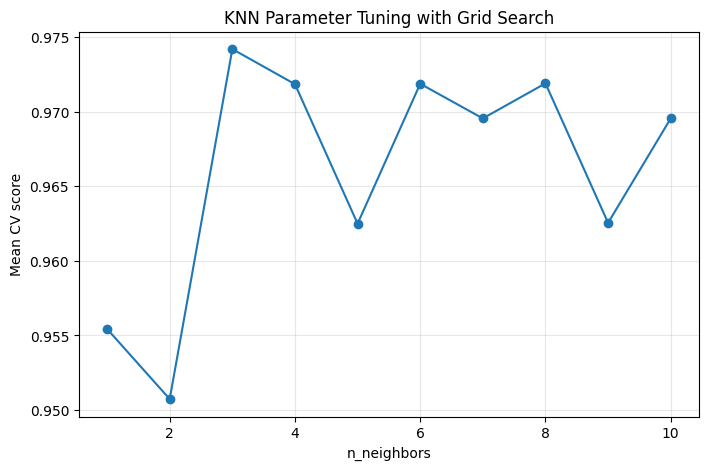

In [49]:
knn_results = pd.DataFrame(grid_knn.cv_results_)

plt.figure(figsize=(8, 5))
plt.plot(knn_results["param_knn__n_neighbors"].astype(int),
         knn_results["mean_test_score"],
         marker='o')
plt.xlabel("n_neighbors")
plt.ylabel("Mean CV score")
plt.title("KNN Parameter Tuning with Grid Search")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretasi

Grafik di atas membantu melihat nilai parameter mana yang paling baik. Biasanya ada titik tertentu di mana performa model paling tinggi, lalu setelah itu justru menurun lagi.

Dari sini terlihat bahwa memilih parameter bukan sekadar coba-coba, tetapi memang perlu diuji secara sistematis.

## Kesimpulan Chapter 5

Setelah menjalankan chapter ini, saya memahami beberapa hal penting:

1. **Train-test split saja belum cukup** untuk mengevaluasi model dengan baik.
2. **Cross-validation** memberikan hasil evaluasi yang lebih stabil karena model diuji pada beberapa pembagian data.
3. **Grid search** membantu mencari parameter terbaik secara sistematis.
4. **Pipeline** sangat penting untuk membuat workflow lebih rapi dan mencegah data leakage.
5. Pemilihan parameter dan cara evaluasi sangat berpengaruh terhadap performa akhir model.

Menurut saya, chapter ini sangat penting karena mulai mengajarkan bahwa membuat model machine learning bukan hanya soal training model, tetapi juga soal **bagaimana mengevaluasi dan memilih model dengan benar**.